In [ ]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [1]:
#!unzip model.zip

Archive:  model.zip
   creating: model/
  inflating: model/activations.py    
  inflating: model/gradients.py      
  inflating: model/linear_model.py   
  inflating: model/metrics.py        
  inflating: model/utils.py          
   creating: model/__pycache__/
  inflating: model/__pycache__/metrics.cpython-310.pyc  
   creating: data/
   creating: data/linear_data/
  inflating: data/linear_data/linear_data_A.npz  
  inflating: data/linear_data/linear_data_B.npz  
  inflating: data/linear_data/linear_data_C.npz  
  inflating: data/linear_data/linear_data_D.npz  
   creating: data/logistic_data/
  inflating: data/logistic_data/logistic_data_A.npz  
  inflating: data/logistic_data/logistic_data_B.npz  
  inflating: data/logistic_data/logistic_data_C.npz  
  inflating: data/logistic_data/logistic_data_D.npz  
  inflating: data/NYCU_Iris.csv      


In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt
import numpy as np

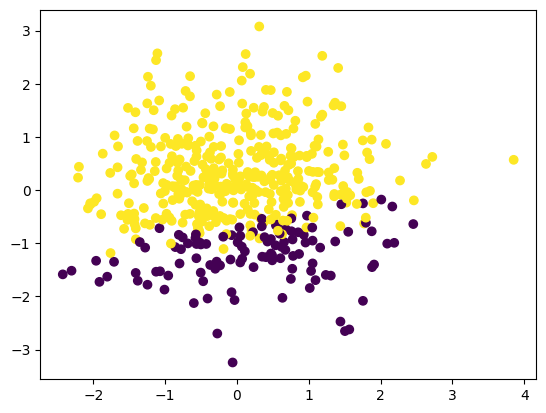

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [4]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.7007176536422792
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.5025287985878911, Val loss:0.5015278107602669
400. Training loss: 0.472286903656601, Val loss:0.47335285416404
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430745, Val loss:0.43054684173876917
550. Training loss: 0.4081728908570478, Val loss:0.4139746471541715
600. Training loss: 0.39272216283590505, Val loss:0.39973270897578933
650. Training loss: 0.3792774530955586, Val loss:0.38735889620900993
700. Training loss: 0.3674662456334753, Val loss:0.3765019336049603
750. Training loss: 0.35700075616242133, Val lo

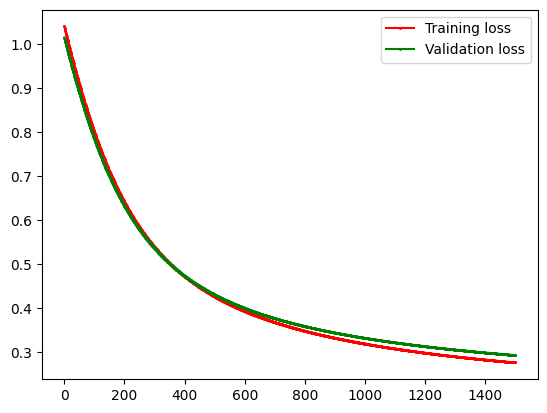

In [5]:
# Train the model
from model.linear_model import LinearModel


seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =1500,val_ratio=0.2)

In [6]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9025
Precision : 0.9083
Recall    : 0.9124
F1-score  : 0.9103


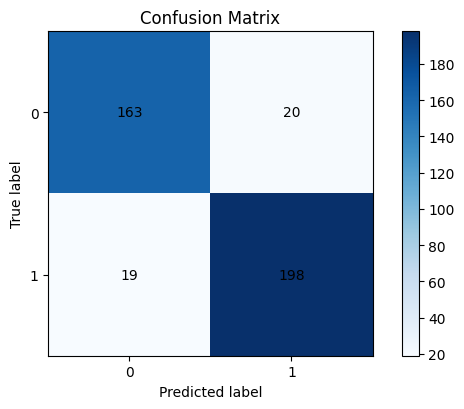

{'Accuracy': 0.9025,
 'Precision': 0.908256880733945,
 'Recall': 0.9124423963133641,
 'F1-score': 0.9103448275862069}

In [7]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

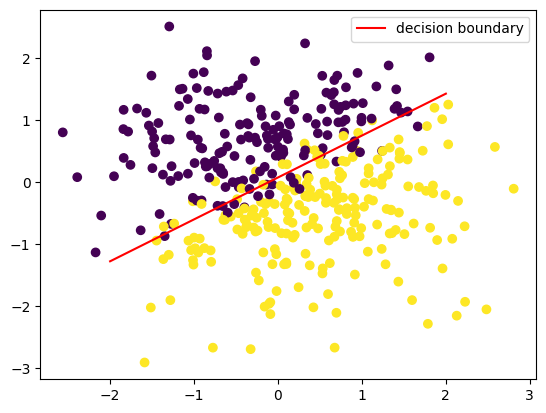

In [8]:
# Plot
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()